# PCHN63112 Workshop: Longitudinal Data Example

## Loading Packages
We will start by loading all the packages that we need at the beginning. This will tidy-up the output, allow any messages or warnings to not clutter up the rest of the output and not bury any packages within the main body of the analysis. We also use `source()` on the file `plot-lme.R`. This needs to be in the current working directory and will bring the custom function `plot.lme()` into scope.

In [1]:
library('lattice')   # plotting functions
library('Matrix')    # covariance extraction and visualisation
library('nlme')      # mixed-effects modelling
library('car')       # Asymptotic ANOVA tests
library('emmeans')   # Follow-up tests
library('effects')   # Effects plots from the model
source('plot-lme.R') # custom plot.lme() function for making assumptions plots

Loading required package: carData
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Use the command
    lattice::trellis.par.set(effectsTheme())
  to customize lattice options for effects plots.
See ?effectsTheme for details.


## The Autism Data
The data we will use concern measurements of socialisation in 158 children diagnosed with autism spectrum disorder (ASD). The children were measured at ages 2, 3, 5, 9, and 13. The outcome variable is the Vineland Socialisation Age Equivalent (VSAE) score, which combines multiple assessments of socialisation at each age. Also of interest was the children's initial language development. This was measured using the Sequenced Inventory of Communication Development (SICD) at age 2 and the children were placed into groups depending upon whether they scored *low*, *medium* or *high* on the expressive language subscale. The main interest of the study was to assess how socialisation improved over time, as well as whether this improvement had any relationship with the child's initial language skills at age 2.

The data are available to download from [here](https://websites.umich.edu/~bwest/chapter6.html). Once downloaded to the current working directory, the code below will read the data in and then print the values for the first 3 children.

In [2]:
autism <- read.csv('autism.csv')
autism[1:14,]

   age vsae sicdegp childid
1    2    6       3       1
2    3    7       3       1
3    5   18       3       1
4    9   25       3       1
5   13   27       3       1
6    2   17       3       3
7    3   18       3       3
8    5   12       3       3
9    9   18       3       3
10  13   24       3       3
11   2   12       3       4
12   3   14       3       4
13   5   38       3       4
14   9  114       3       4

As this is already long-formatted, we just need to convert the relevant variables to factors. We also rename the levels associated with `sicdegp` factor to make their meaning clearer.

In [3]:
autism$childid <- as.factor(autism$childid)
autism$sicdegp <- as.factor(autism$sicdegp)

levels(autism$sicdegp) <- c('low','medium','high')

We can now briefly summarise all the variables to check everything is in order.

In [4]:
summary(autism)

      age              vsae          sicdegp       childid   
 Min.   : 2.000   Min.   :  1.00   low   :192   1      :  5  
 1st Qu.: 2.000   1st Qu.: 10.00   medium:255   2      :  5  
 Median : 4.000   Median : 14.00   high  :165   3      :  5  
 Mean   : 5.771   Mean   : 26.41                14     :  5  
 3rd Qu.: 9.000   3rd Qu.: 27.00                15     :  5  
 Max.   :13.000   Max.   :198.00                17     :  5  
                  NA's   :2                     (Other):582  

Of note is that VSAE has a very wide range, from 1-198, and also contains two missing values. This indicates that there were some occasions when a particular child was not measured. There are also more children in the `medium` SICDEGP group than the others, making the data *unbalanced* in relation to this factor. Also note that `childid` does not run sequentially, as these data represent a subset of children who participated in this study.

### Model Notation
As these data are a mixture of *categorical* and *continuous* variables, a more general regression framework will be needed when writing this model. In what follows, we will use *descriptive labels* rather than greek letter for categorical variables (e.g. $\text{SICDEGP}_{j}$ rather than $\alpha_{j}$) and will introduce $\beta$-coefficients for continuous variables (e.g. $\left(\beta_{1} \times \text{age}_{i}\right)$ rather than $\beta_{1}x_{i1}$). This should hopefully make it clearer which terms are categorical and which are continuous. In reality, the whole model is fit as a regression with dummy variables in place of the categorical predictors. However, it can be less clear to write the model this way, even if this is the reality of how it is fit.

## Data Structure
Although we already know what structure these data have, we will run through the logic for completeness. 

Firstly, we need to determine our *unit of analysis*. In this example, our model is trying to explain the socialisation skills of children with ASD. The entities that our model is describing are the scores of the children, and so our units of analysis are the *children* themselves.   

Secondly, we determine what each *row* of the long-formatted data represents in relation to the units of analysis. Examining the first few rows

In [5]:
head(autism)

  age vsae sicdegp childid
1   2    6    high       1
2   3    7    high       1
3   5   18    high       1
4   9   25    high       1
5  13   27    high       1
6   2   17    high       3

we can see that each row corresponds to a single unit (*child*) measured *multiple times*. So these are either *repeated measurements* or *longitudinal* data. The difference lies in whether there is an explicit measurement of time here. As we can see, the different repeats are indexed by the values of `age`. Importantly, these values have an *order* that must be maintained and the temporal gap between successive values is not uniform. The time scale is also meaningful, as it is measured in *years*. As such, this is *longitudinal* data.

Finally, we need to determine whether there are any *clustering* variables that represent a higher-order dependency structure in these data. The only potential candidate is `sicdegp`, but we know from the data description above that this is an artificial experimental grouping based on the child's language skills at age 2. It is not indicative of a shared context of environment that binds different children together. As such, this is clearly a *grouping* variable rather than a *clustering* variable. Based on this, we can construct the following table of the *levels* of these data, using the guidance in the lesson

| **Data Type**    | **Longitudinal**  | 
|------------------|-------------------|
| **Dataset**      | `autism`          |
| **Level 1**      | Repeats over time |
| **Level 2**      | *Child*           |
| **Level 3**      | -                 |

Because these data are quite simple, we can get an initial sense of their structure by constructing a graph of child-specific trajectories over time for each level of `sicdegp`

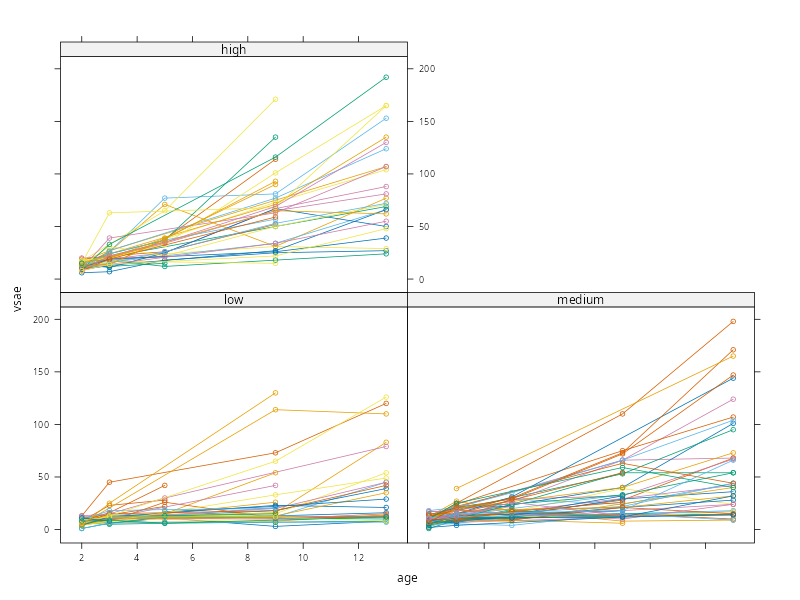

In [6]:
xyplot(
  vsae ~ age|sicdegp, # x-axis=age, panel=SICDe Group
  groups = childid,   # separate lines per-child
  data   = autism,    # data
  type   = "b"        # lines with points
)

Several patterns are noticeable here. Firstly, the variance appears to increase as a function of `age`, getting wider and wider as `age` increases. Whatever model we choose, we will need to make sure that the variance estimated for each value of time increases appropriately. Secondly, there is a slight hint that some of these trajectories are not *linear*, rather they *bend* upwards. As such, we may wish to entertain a *quadratic* model of time as well. Finally, it does not look as if the variance between these trajectories differs majorly between the levels of `sicdegp`, but this is something we could consider.

## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure which, in this example, is a single *child*. We choose the first child in the dataset, who is indexed using `childid == '1'`. We subset the data below

In [7]:
autism.1 <- subset(autism, childid=='1')
print(autism.1)

  age vsae sicdegp childid
1   2    6    high       1
2   3    7    high       1
3   5   18    high       1
4   9   25    high       1
5  13   27    high       1


In [8]:
autism.1 <- subset(autism, childid=='1', select= -sicdegp)
print(autism.1)

  age vsae childid
1   2    6       1
2   3    7       1
3   5   18       1
4   9   25       1
5  13   27       1


Our basic model for a single child is therefore

$$
\text{VSAE}_{i} = \beta_{0} + \left(\beta_{1} \times \text{age}_{i}\right) + \eta_{i},
$$

which is just the simple regression of VSAE on age.

$$
\begin{alignat*}{1}
    \text{Level 1} \\
    \text{VSAE}^{(k)}_{ij} &= \beta_{0j}^{(k)} + \left(\beta_{1j}^{(k)} \times \text{age}_{i}\right) + \eta^{(k)}_{ij} \\
    \quad\\
    \text{Level 2} \\
    \beta_{0j}^{(k)} &= \beta_{0} + \text{SICDEGP}_{j} + \xi^{(k)}_{j} \\
    \beta_{1j}^{(k)} &= \beta_{1} + \text{SICDEGP}_{j} + \phi^{(k)}_{j}
\end{alignat*}
$$

The key to seeing how this works is to recognise that we replace $\beta_{1j}^{(k)}$ at Level 1 with its full definition from Level 2. This full definition is then multiplied by $\text{age}_{i}$. So, at Level 1 we have

$$
\beta_{1j}^{(k)} \times \text{age}_{i},
$$

which becomes

$$
\left(\beta_{1} + \text{SICDEGP}_{j} + \phi^{(k)}_{j}\right) \times \text{age}_{i}.
$$

Removing the brackets then results in

$$
\left(\beta_{1} \times \text{age}_{i}\right) + \left(\text{SICDEGP}_{j} \times \text{age}_{i}\right) + \left(\phi^{(k)}_{j} \times \text{age}_{i}\right),
$$

producing the overall slope with age, the interactions between age and SICDEGP and the random per-child slope of age.

$$
\text{VSAE}^{(k)}_{ij} = \beta_{0} + \left(\beta_{1} \times \text{age}_{i}\right) + \text{SICDEGP}_{j} +  \left(\text{age} \times \text{SICDEGP}\right)_{ij} + \xi^{(k)}_{j} + (\phi^{(k)}_{j} \times \text{age}_{i}) +  \eta^{(k)}_{ij}
$$

In [9]:
autism.lme <- lme(fixed     = vsae ~ 1 + age + sicdegp + age:sicdegp, 
                  random    = ~ 1 + age|childid,
                  data      = autism, 
                  na.action = na.omit, 
                  control   = lmeControl(opt='optim')
)

print(autism.lme)

Linear mixed-effects model fit by REML
  Data: autism 
  Log-restricted-likelihood: -2348.065
  Fixed: vsae ~ 1 + age + sicdegp + age:sicdegp 
      (Intercept)               age     sicdegpmedium       sicdegphigh 
        1.8431741         2.9719752        -0.3247815        -3.8581067 
age:sicdegpmedium   age:sicdegphigh 
        0.7151603         4.3348154 

Random effects:
 Formula: ~1 + age | childid
 Structure: General positive-definite, Log-Cholesky parametrization
            StdDev   Corr  
(Intercept) 8.602952 (Intr)
age         4.019888 -0.998
Residual    7.769026       

Number of Observations: 610
Number of Groups: 158 


           1          2          3          4          5
1  60.932515  -1.624765  -6.023787  -14.82183  -23.61988
2  -1.624765  72.692989  40.255191   96.09513  151.93507
3  -6.023787  40.255191 193.170916  317.92906  503.04497
4 -14.821831  96.095133 317.929061  821.95469 1205.26477
5 -23.619876 151.935074 503.044974 1205.26477 1967.84234


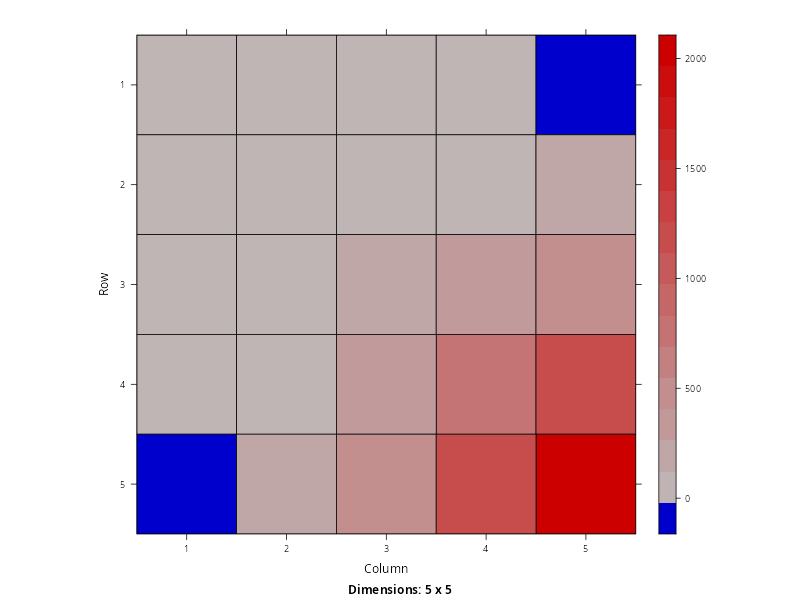

In [10]:
Sigma.1 <- getVarCov(autism.lme, type='marginal', individual='1')$`1`
print(Sigma.1)
image(as(Sigma.1,'Matrix'))

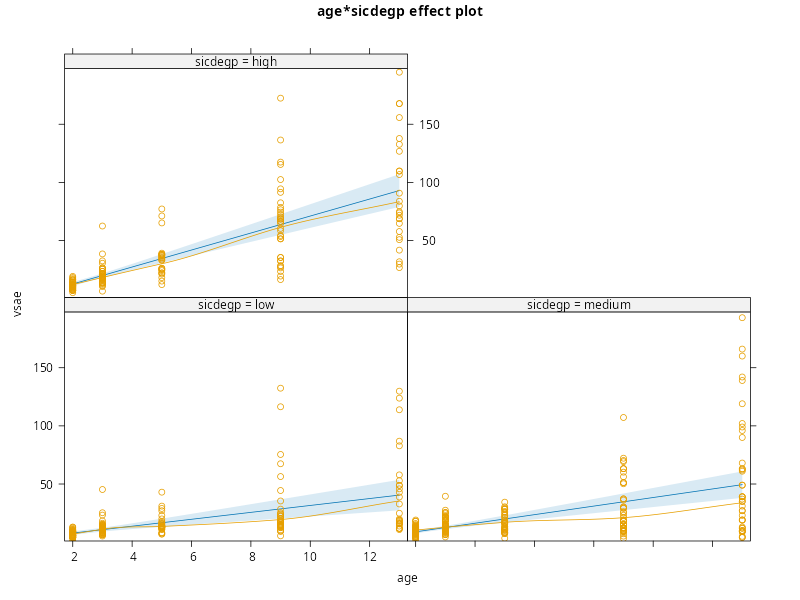

In [11]:
plot(allEffects(autism.lme, residuals=TRUE))

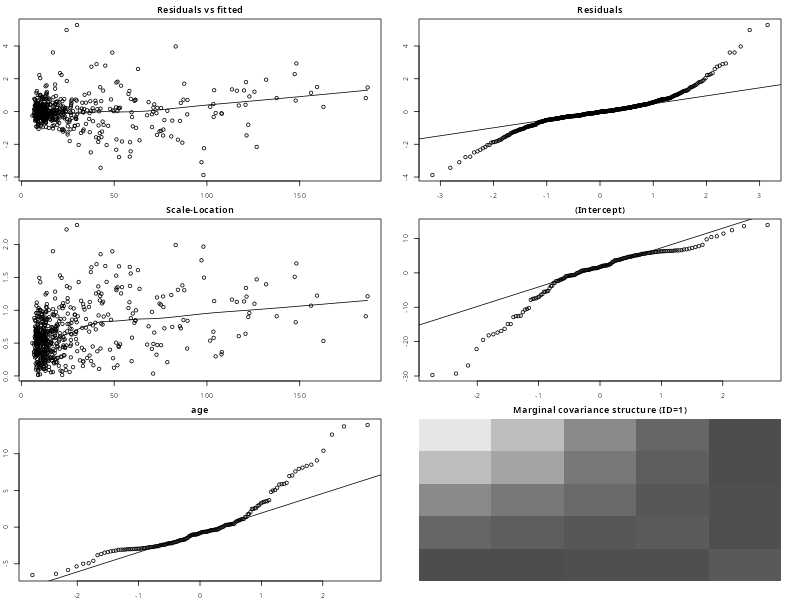

In [12]:
plot.lme(autism.lme, vcov.id='1')

In [13]:
Anova(autism.lme)

Analysis of Deviance Table (Type II tests)

Response: vsae
              Chisq Df Pr(>Chisq)    
age         161.601  1  < 2.2e-16 ***
sicdegp      35.907  2  1.595e-08 ***
age:sicdegp  25.667  2  2.670e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1